# Unsupervised Learning: Clustering pada Dataset Iris

**Metode yang diimplementasikan:** K-Means, Hierarchical (Agglomerative), DBSCAN, dan BIRCH

Dataset Iris terdiri dari 150 sampel bunga iris dengan 4 fitur numerik dan 1 label spesies. Karena ini adalah *unsupervised learning*, label spesies hanya digunakan untuk evaluasi akhir, bukan sebagai input model.

Download dataset: https://www.kaggle.com/datasets/uciml/iris

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('whitegrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [28]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


---
## 1. Basic EDA

In [29]:
df.shape

(150, 6)

In [30]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object

In [31]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [32]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [33]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

---
## 2. Histogram & Boxplot

Melihat distribusi setiap fitur, apakah skewed? apakah ada outlier terlihat?

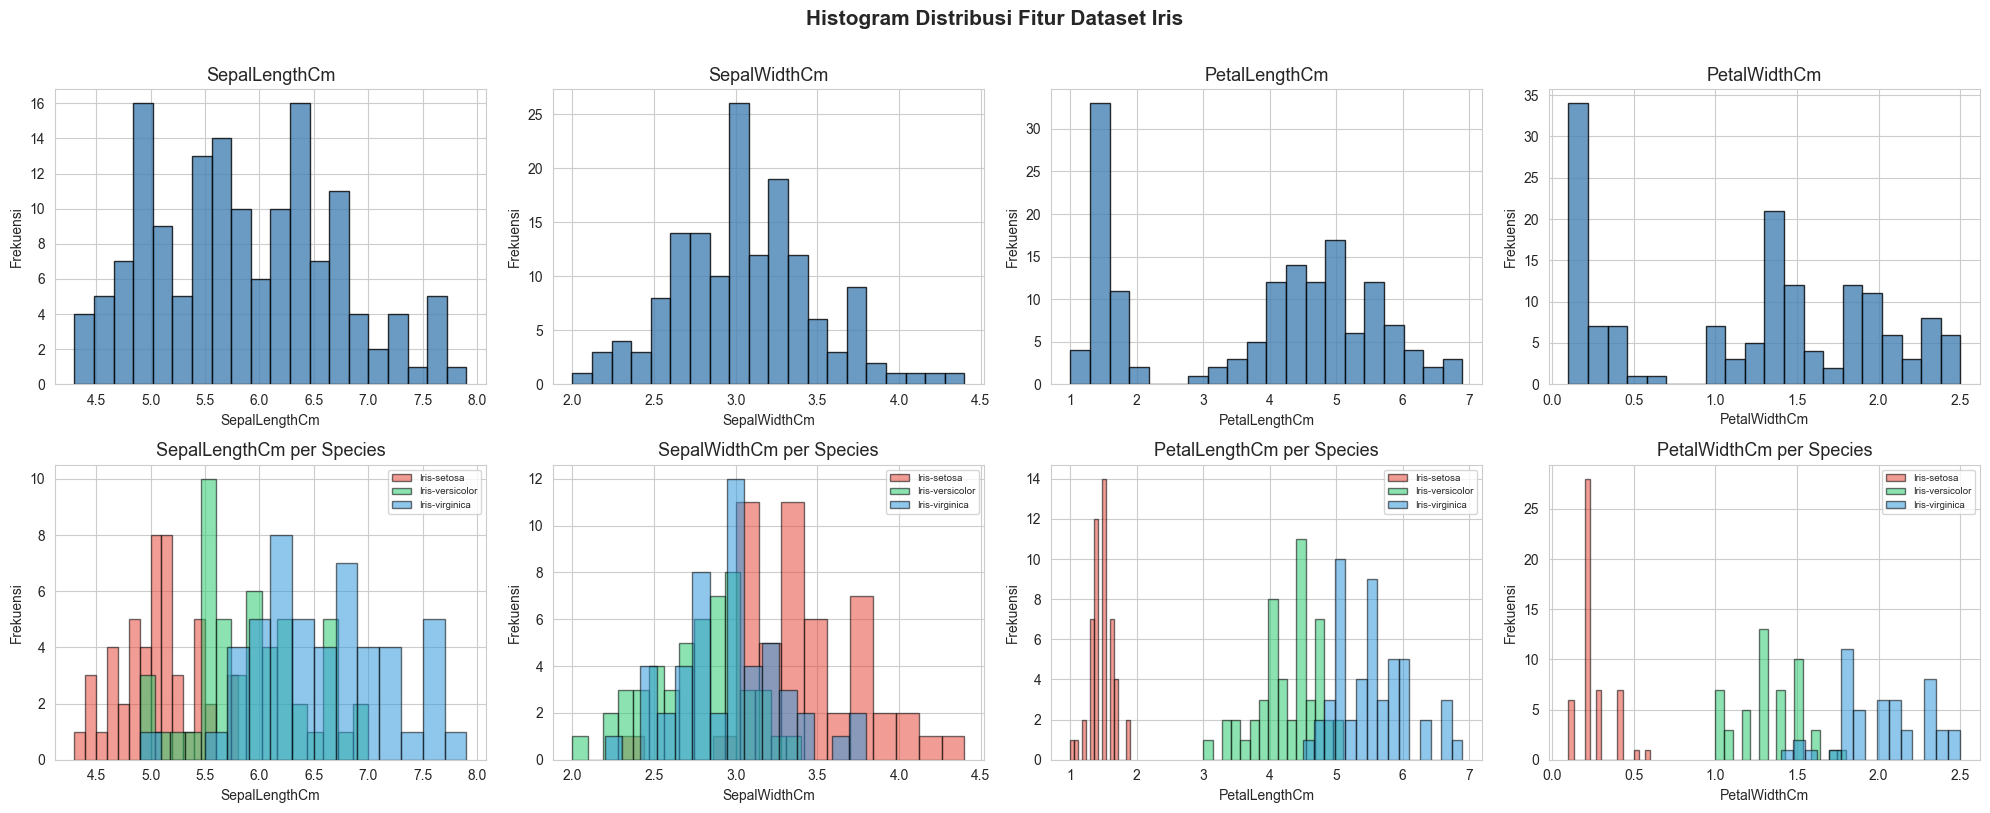

In [34]:
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
species_colors = {'Iris-setosa': '#e74c3c', 'Iris-versicolor': '#2ecc71', 'Iris-virginica': '#3498db'}

# --- Histogram keseluruhan + per species ---
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, feat in enumerate(features):
    # Row 0: histogram keseluruhan
    axes[0, i].hist(df[feat], bins=20, color='steelblue', edgecolor='black', alpha=0.8)
    axes[0, i].set_title(f'{feat}')
    axes[0, i].set_xlabel(feat)
    axes[0, i].set_ylabel('Frekuensi')
    
    # Row 1: histogram per species (overlay)
    for species, color in species_colors.items():
        subset = df[df['Species'] == species][feat]
        axes[1, i].hist(subset, bins=15, alpha=0.55, color=color, edgecolor='black', label=species)
    axes[1, i].set_title(f'{feat} per Species')
    axes[1, i].set_xlabel(feat)
    axes[1, i].set_ylabel('Frekuensi')
    axes[1, i].legend(fontsize=7)

fig.suptitle('Histogram Distribusi Fitur Dataset Iris', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

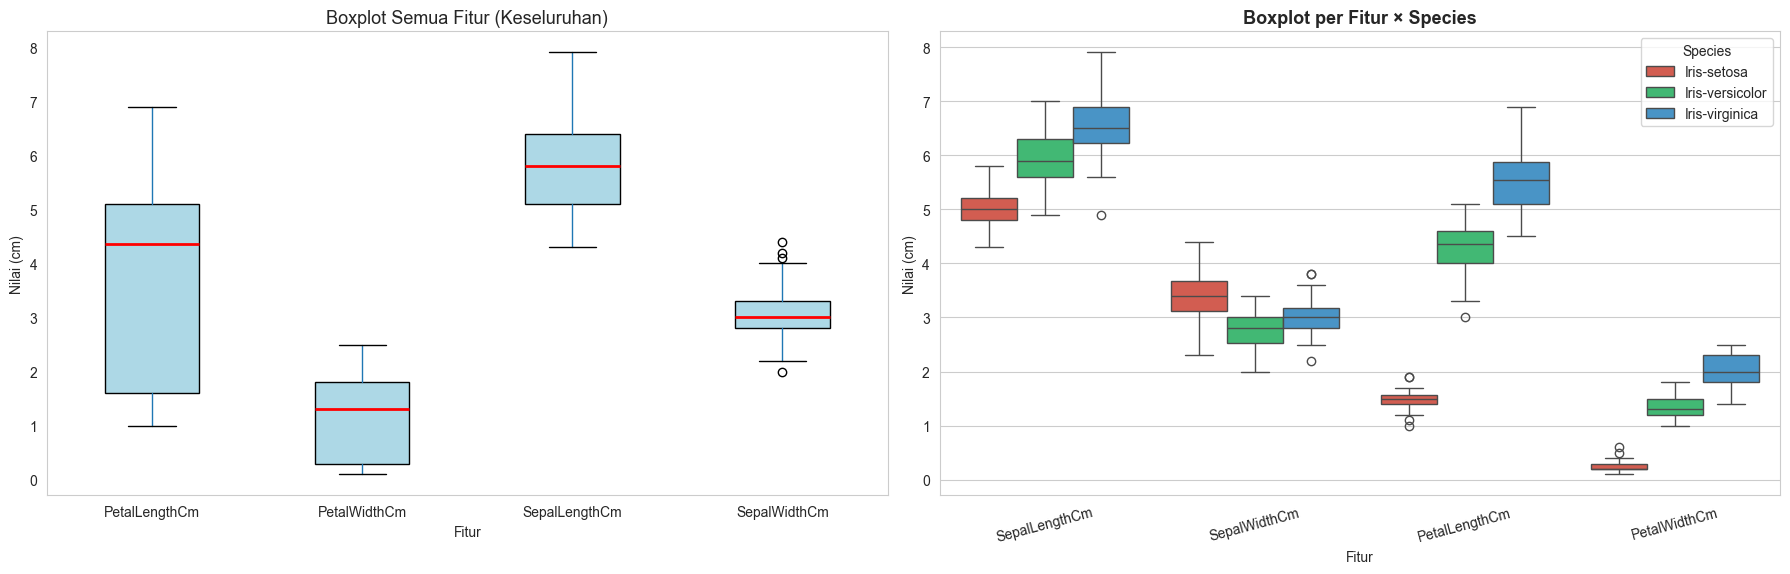

In [35]:
# --- Boxplot keseluruhan & per species ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot keseluruhan (melt agar bisa plot sekaligus)
df_melt = df[features].melt(var_name='Fitur', value_name='Nilai')
axes[0].set_title('Boxplot Semua Fitur (Keseluruhan)', fontweight='bold')
df_melt.boxplot(column='Nilai', by='Fitur', ax=axes[0], grid=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
axes[0].set_xlabel('Fitur')
axes[0].set_ylabel('Nilai (cm)')
plt.sca(axes[0])
plt.title('Boxplot Semua Fitur (Keseluruhan)')

# Boxplot per species
df_melt2 = df[features + ['Species']].melt(id_vars='Species', var_name='Fitur', value_name='Nilai')
axes[1].set_title('Boxplot per Species', fontweight='bold')
sns.boxplot(data=df_melt2, x='Fitur', y='Nilai', hue='Species',
            palette=species_colors, ax=axes[1])
axes[1].set_title('Boxplot per Fitur × Species', fontweight='bold')
axes[1].set_xlabel('Fitur')
axes[1].set_ylabel('Nilai (cm)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('')
plt.tight_layout()
plt.show()

---
## 3. Visualisasi Data di Koordinat

Pair plot dan heatmap korelasi untuk melihat separabilitas antar spesies, ini membantu memilih metode clustering yang tepat.

- Jika cluster **compact & well-separated** → K-Means cocok
- Jika cluster **berbentuk arbitrary / tidak bulat** → DBSCAN lebih baik
- Cluster dengan **density berbeda** → BIRCH bisa handle
- Hirarki antar kelompok → **Hierarchical Clustering**

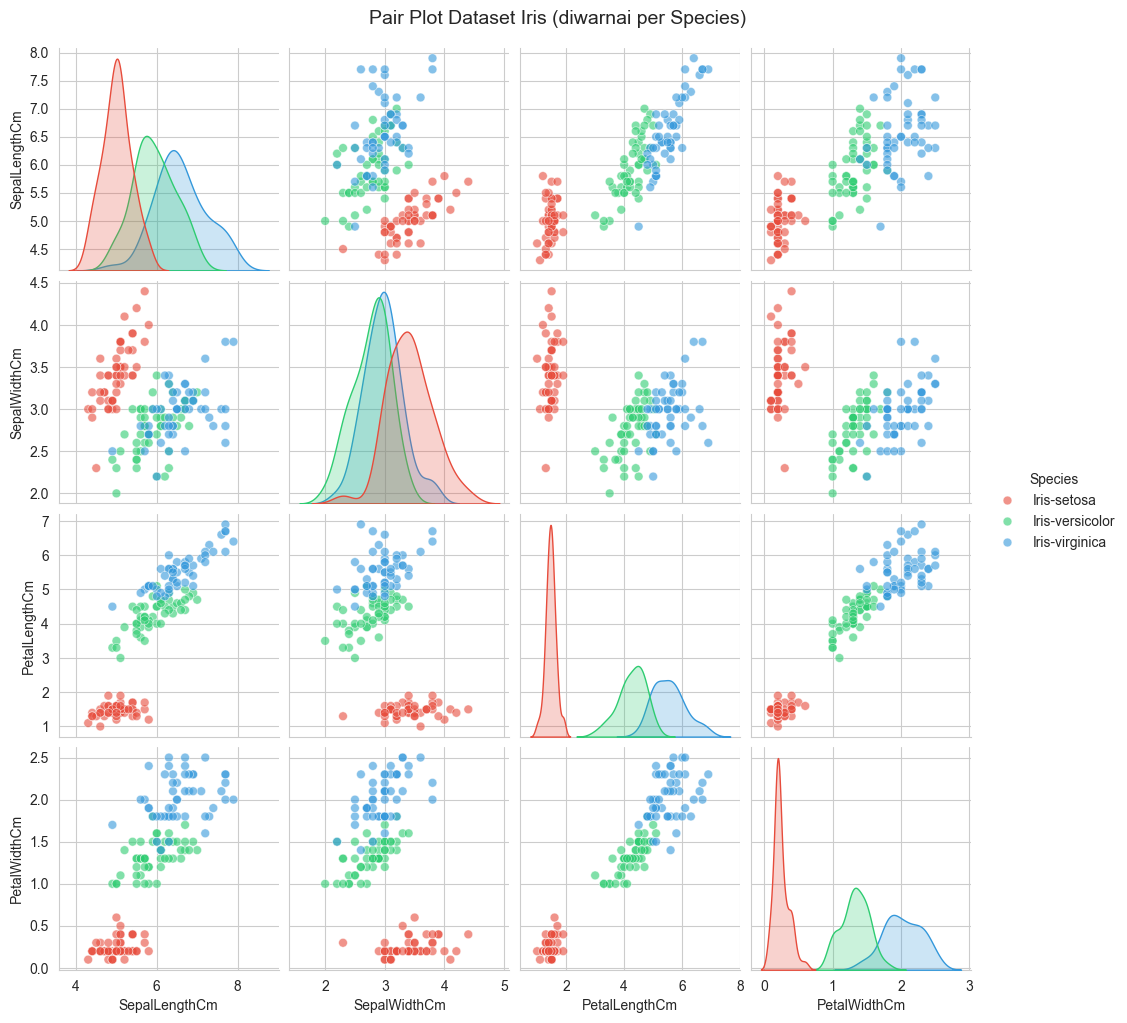

In [36]:
# Pair Plot — scatter antar semua kombinasi fitur, diwarnai per species (referensi)
g = sns.pairplot(df[features + ['Species']], hue='Species',
                 palette=species_colors, diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 40})
g.fig.suptitle('Pair Plot Dataset Iris (diwarnai per Species)', y=1.02, fontsize=14)
plt.show()

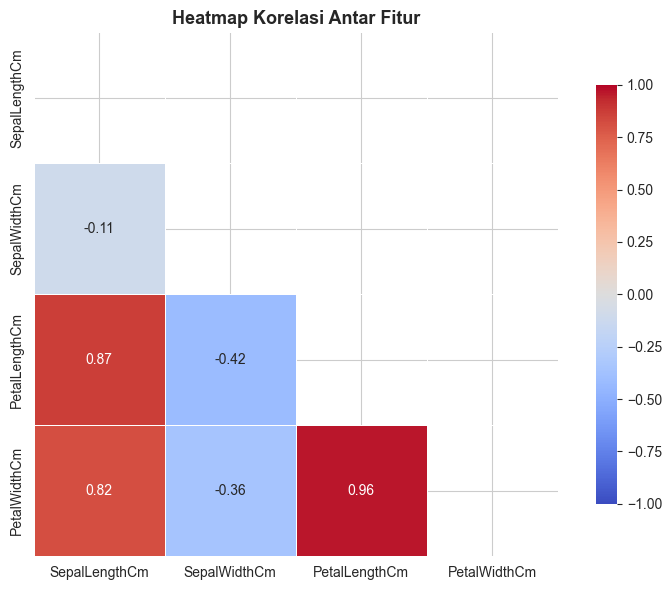


Insight:
- PetalLengthCm & PetalWidthCm berkorelasi sangat tinggi (>0.9)
- SepalLengthCm berkorelasi kuat dengan fitur Petal
- SepalWidthCm hampir tidak berkorelasi dengan fitur lain


In [37]:
# Heatmap Korelasi
plt.figure(figsize=(8, 6))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Heatmap Korelasi Antar Fitur', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInsight:")
print("- PetalLengthCm & PetalWidthCm berkorelasi sangat tinggi (>0.9)")
print("- SepalLengthCm berkorelasi kuat dengan fitur Petal")
print("- SepalWidthCm hampir tidak berkorelasi dengan fitur lain")

---
## 4. Deteksi & Penghapusan Outlier

Menggunakan metode **IQR (Interquartile Range)**:
- Batas bawah = Q1 − 1.5 × IQR
- Batas atas = Q3 + 1.5 × IQR
- Data di luar batas dihapus

In [38]:
def remove_outliers_iqr(dataframe, cols):
    df_clean = dataframe.copy()
    outlier_info = {}
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        removed = before - len(df_clean)
        outlier_info[col] = {'Q1': round(Q1, 3), 'Q3': round(Q3, 3),
                             'IQR': round(IQR, 3), 'lower': round(lower, 3),
                             'upper': round(upper, 3), 'removed': removed}
    return df_clean, outlier_info

df_clean, outlier_info = remove_outliers_iqr(df, features)

print(f"{'Fitur':<20} {'Q1':>6} {'Q3':>6} {'IQR':>6} {'Lower':>7} {'Upper':>7} {'Removed':>8}")
print("-" * 67)
for col, info in outlier_info.items():
    print(f"{col:<20} {info['Q1']:>6} {info['Q3']:>6} {info['IQR']:>6} "
          f"{info['lower']:>7} {info['upper']:>7} {info['removed']:>8}")

print(f"\nShape sebelum : {df.shape}")
print(f"Shape sesudah  : {df_clean.shape}")
print(f"Total dihapus  : {len(df) - len(df_clean)} baris")
print(f"\nDistribusi Species setelah cleaning:")
print(df_clean['Species'].value_counts())

Fitur                    Q1     Q3    IQR   Lower   Upper  Removed
-------------------------------------------------------------------
SepalLengthCm           5.1    6.4    1.3    3.15    8.35        0
SepalWidthCm            2.8    3.3    0.5    2.05    4.05        4
PetalLengthCm           1.6    5.1    3.5   -3.65   10.35        0
PetalWidthCm            0.3    1.8    1.5   -1.95    4.05        0

Shape sebelum : (150, 6)
Shape sesudah  : (146, 6)
Total dihapus  : 4 baris

Distribusi Species setelah cleaning:
Species
Iris-virginica     50
Iris-versicolor    49
Iris-setosa        47
Name: count, dtype: int64


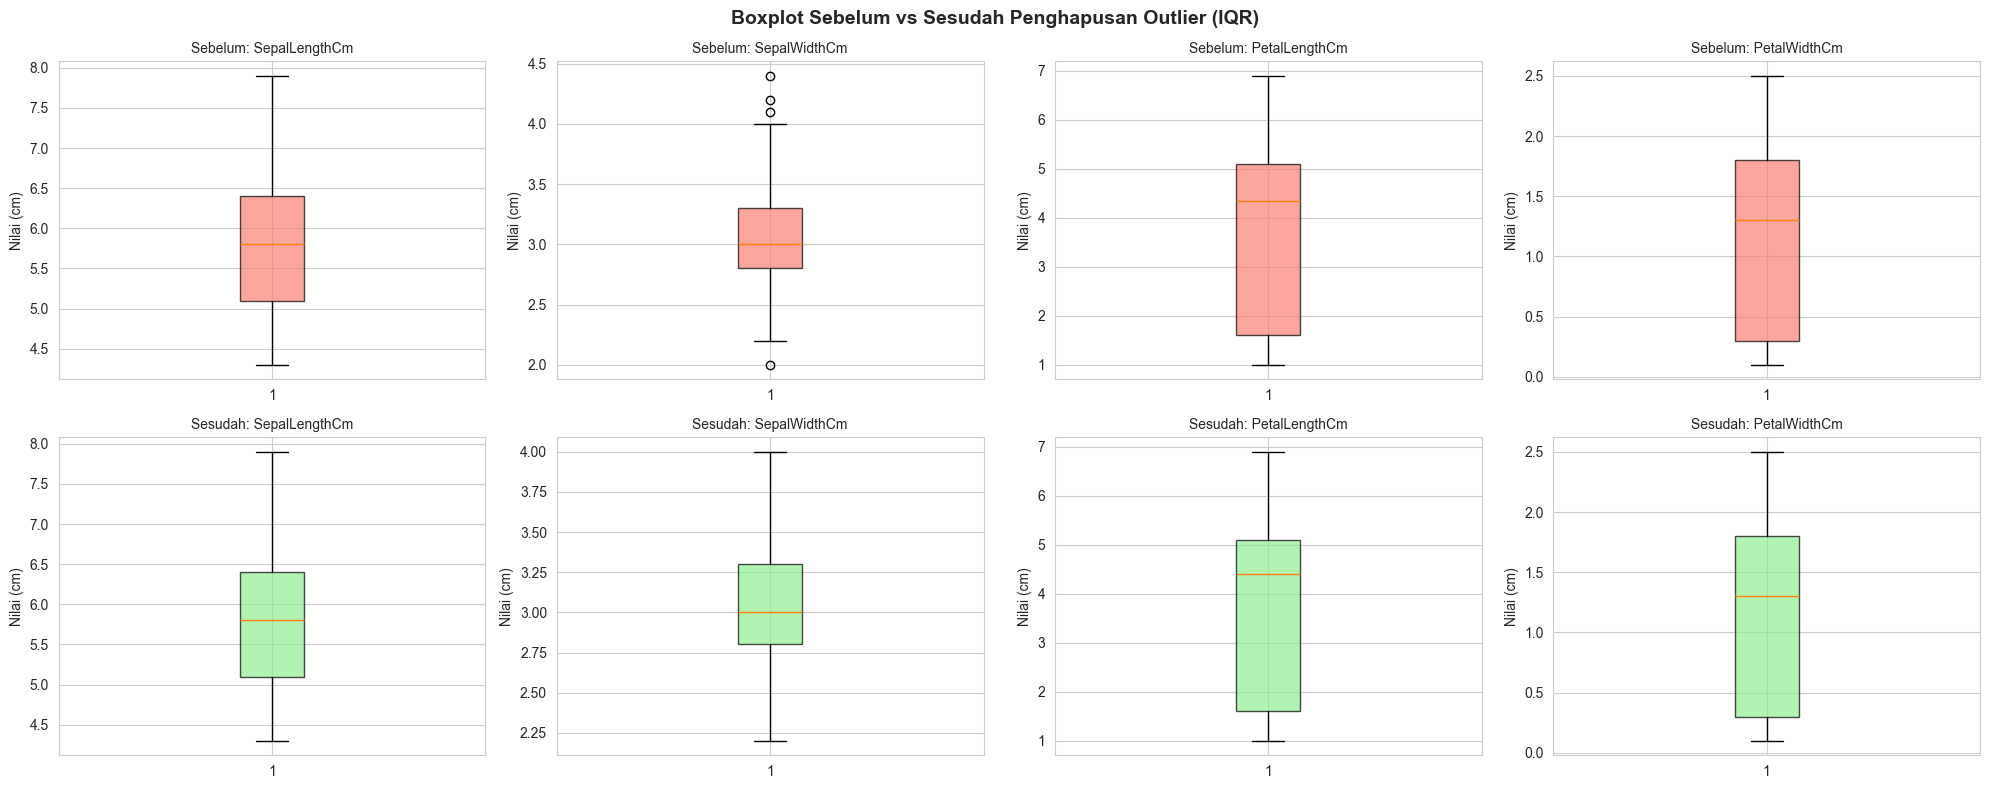

In [39]:
# Visualisasi perbandingan sebelum & sesudah cleaning
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, feat in enumerate(features):
    # Sebelum
    axes[0, i].boxplot(df[feat], patch_artist=True,
                       boxprops=dict(facecolor='salmon', alpha=0.7))
    axes[0, i].set_title(f'Sebelum: {feat}', fontsize=10)
    axes[0, i].set_ylabel('Nilai (cm)')
    
    # Sesudah
    axes[1, i].boxplot(df_clean[feat], patch_artist=True,
                       boxprops=dict(facecolor='lightgreen', alpha=0.7))
    axes[1, i].set_title(f'Sesudah: {feat}', fontsize=10)
    axes[1, i].set_ylabel('Nilai (cm)')

fig.suptitle('Boxplot Sebelum vs Sesudah Penghapusan Outlier (IQR)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
# Persiapan data setelah outlier removal (tanpa scaling)
df_clean = df_clean.reset_index(drop=True)
X = df_clean[features].values
y_true = df_clean['Species'].values

print(f"Data siap untuk clustering: {X.shape[0]} sampel, {X.shape[1]} fitur")

Data siap untuk clustering: 146 sampel, 4 fitur


---
## 5. K-Means Clustering

**K-Means** mempartisi data ke dalam *k* cluster dengan meminimalkan *Within-Cluster Sum of Squares (WCSS)*.

**Cara menentukan k optimal:**
1. **Elbow Method** : plot WCSS vs k, pilih titik "siku"
2. **Silhouette Method** : pilih k dengan Silhouette Score tertinggi

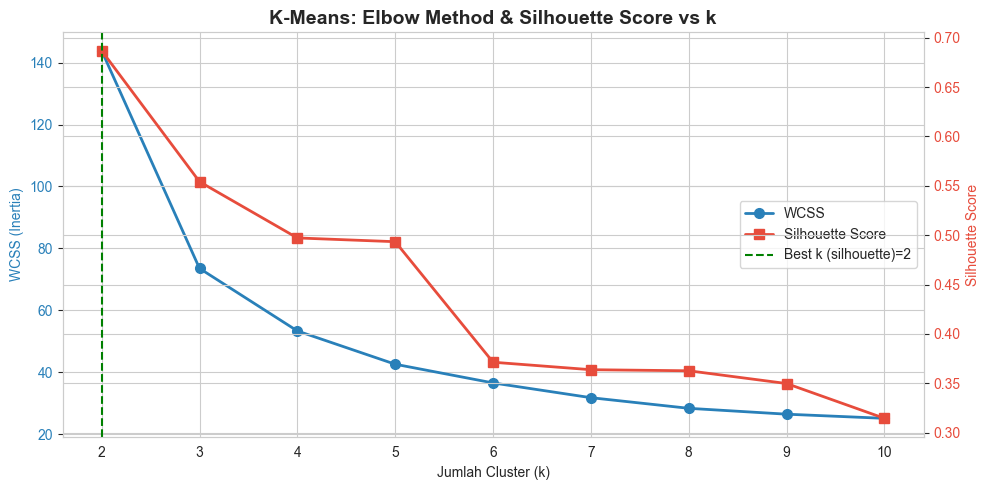

In [ ]:
# Elbow Method + Silhouette Score untuk menentukan k optimal
k_range = range(2, 11)
wcss = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, km.labels_))

# ni pake silhouette score guys
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]

fig, ax1 = plt.subplots(figsize=(10, 5))

color_wcss = '#2980b9'
ax1.set_xlabel('Jumlah Cluster (k)')
ax1.set_ylabel('WCSS (Inertia)', color=color_wcss)
ax1.plot(list(k_range), wcss, 'o-', color=color_wcss, linewidth=2, markersize=7, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color_wcss)
ax1.set_xticks(list(k_range))

ax2 = ax1.twinx()
color_sil = '#e74c3c'
ax2.set_ylabel('Silhouette Score', color=color_sil)
ax2.plot(list(k_range), silhouette_scores, 's-', color=color_sil, linewidth=2, markersize=7, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color_sil)
ax2.axvline(x=best_k, color='green', linestyle='--', linewidth=1.5, label=f'Best k (silhouette)={best_k}')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('K-Means: Elbow Method & Silhouette Score vs k', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


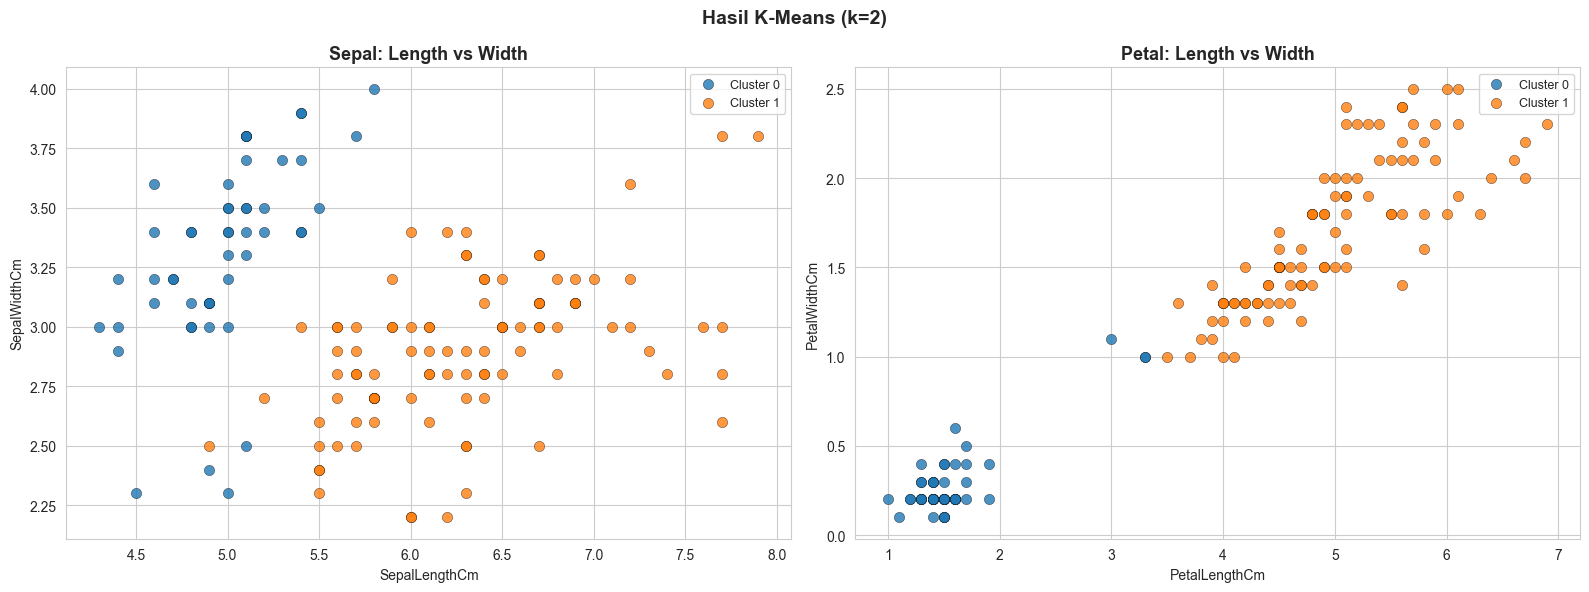

=== Evaluasi K-Means (k=2) ===
  Silhouette Score       : 0.6868  (lebih tinggi = lebih baik)
  Davies-Bouldin Score   : 0.3944  (lebih rendah = lebih baik)
  Calinski-Harabasz Score: 511.67  (lebih tinggi = lebih baik)


In [ ]:
# disini kalian coba aja, bagusan K = 2 atau K = 3, kalian bandingin aja dari evaluasinya.
k_opt = best_k
kmeans = KMeans(n_clusters=k_opt, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

scatter_clusters(X, kmeans_labels, f'Hasil K-Means (k={k_opt})')

# Evaluasi
sil_km = silhouette_score(X, kmeans_labels)
db_km  = davies_bouldin_score(X, kmeans_labels)
ch_km  = calinski_harabasz_score(X, kmeans_labels)

print(f"=== Evaluasi K-Means (k={k_opt}) ===")
print(f"  Silhouette Score       : {sil_km:.4f}  (lebih tinggi = lebih baik)")
print(f"  Davies-Bouldin Score   : {db_km:.4f}  (lebih rendah = lebih baik)")
print(f"  Calinski-Harabasz Score: {ch_km:.2f}  (lebih tinggi = lebih baik)")


---
## 7. Hierarchical Clustering (Agglomerative)

**Hierarchical Clustering** membangun hirarki cluster secara *bottom-up* (setiap titik awalnya cluster sendiri, lalu digabung secara bertahap).

**Dendrogram** divisualisasikan terlebih dahulu untuk membantu memilih jumlah cluster yang optimal dengan melihat "potongan" pada jarak terbesar.

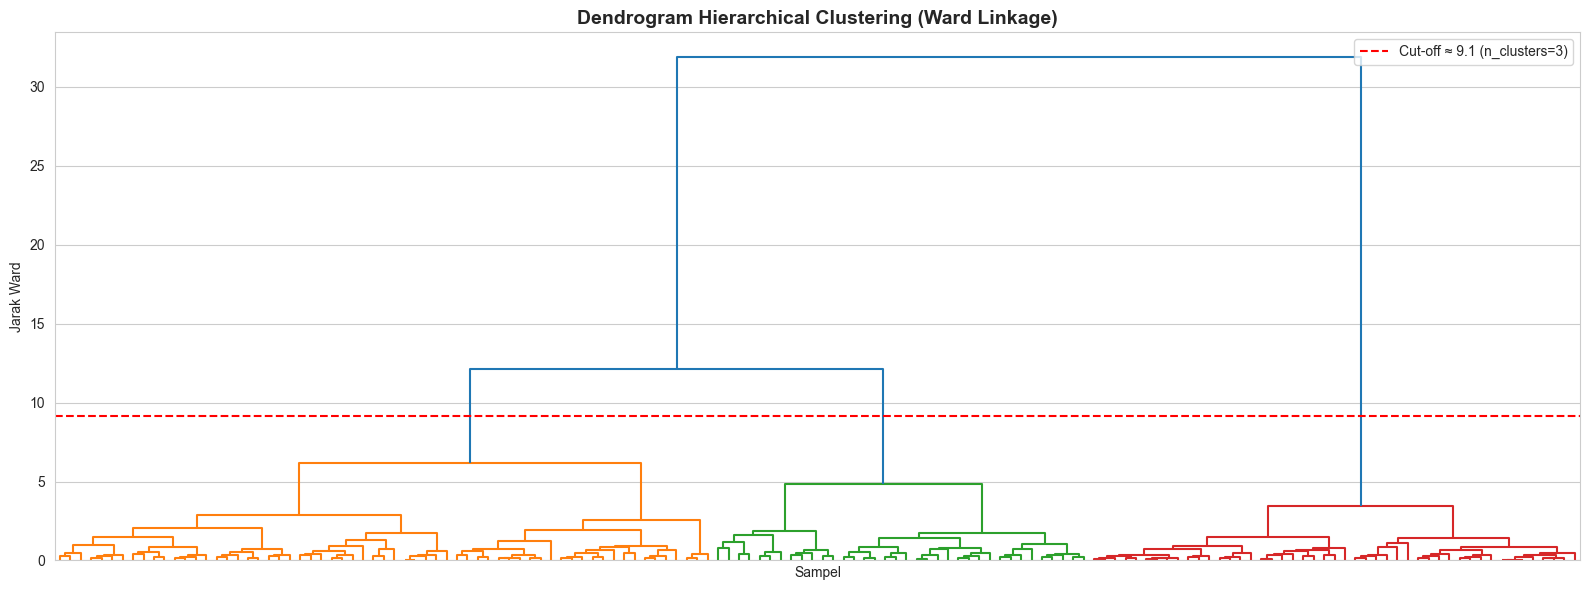

Cut-off otomatis: 9.13  → memotong dendrogram di 3 cluster.


In [ ]:
# Dendrogram menggunakan metode Ward
linked = linkage(X, method='ward')

cutoff = (linked[-3, 2] + linked[-2, 2]) / 2

plt.figure(figsize=(16, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           no_labels=True,
           color_threshold=cutoff)
plt.title('Dendrogram Hierarchical Clustering (Ward Linkage)', fontweight='bold', fontsize=14)
plt.xlabel('Sampel')
plt.ylabel('Jarak Ward')
plt.axhline(y=cutoff, color='red', linestyle='--', linewidth=1.5,
            label=f'Cut-off ≈ {cutoff:.1f} (n_clusters=3)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Cut-off otomatis: {cutoff:.2f}  → memotong dendrogram di 3 cluster.")

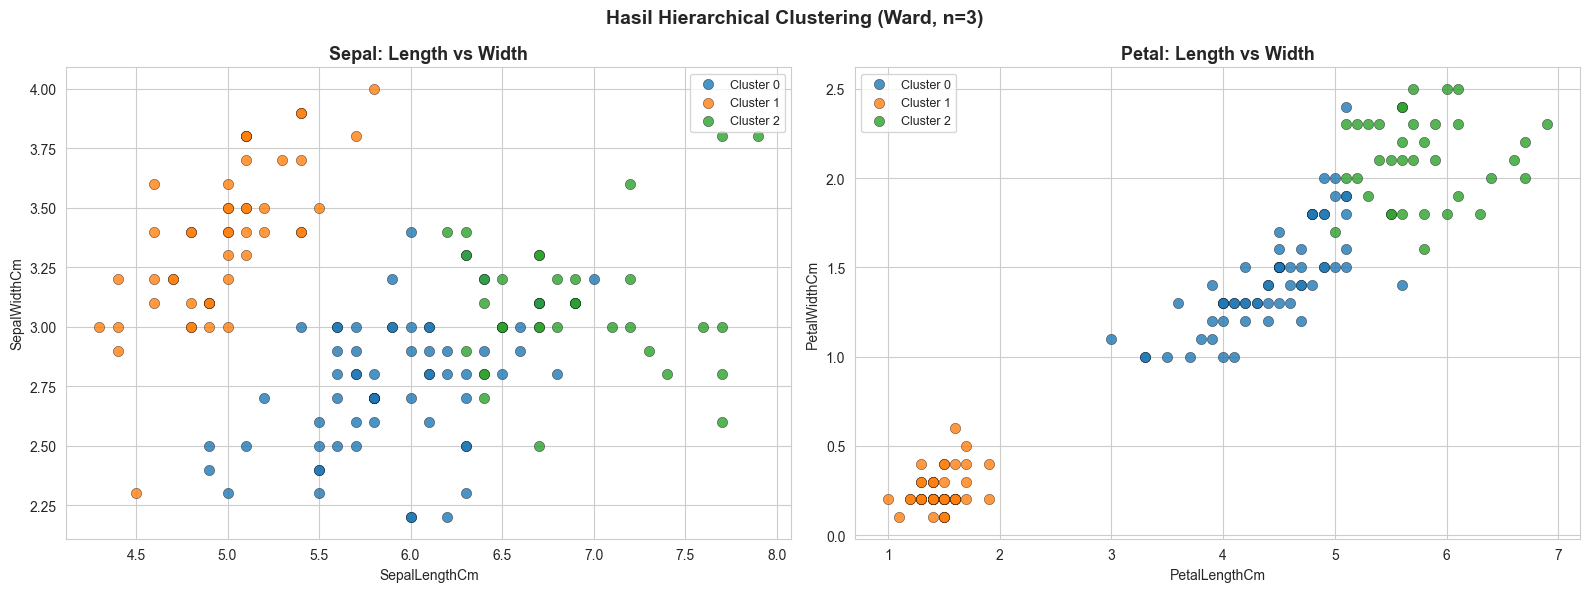

=== Evaluasi Hierarchical Clustering ===
  Silhouette Score       : 0.5559
  Davies-Bouldin Score   : 0.6531
  Calinski-Harabasz Score: 562.48


In [44]:
# Fit Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X)

scatter_clusters(X, agg_labels, 'Hasil Hierarchical Clustering (Ward, n=3)')

# Evaluasi
sil_agg = silhouette_score(X, agg_labels)
db_agg  = davies_bouldin_score(X, agg_labels)
ch_agg  = calinski_harabasz_score(X, agg_labels)

print(f"=== Evaluasi Hierarchical Clustering ===")
print(f"  Silhouette Score       : {sil_agg:.4f}")
print(f"  Davies-Bouldin Score   : {db_agg:.4f}")
print(f"  Calinski-Harabasz Score: {ch_agg:.2f}")

---
## 8. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN menemukan cluster berdasarkan **kepadatan titik** dalam radius tertentu.  
Parameter utama:
- **`eps`** (ε) — radius neighborhood
- **`min_samples`** — jumlah titik minimum dalam radius ε untuk membentuk core point

**Cara menentukan `eps`**: Plot jarak k-nearest neighbor (k = `min_samples`) yang diurutkan → cari titik "elbow".

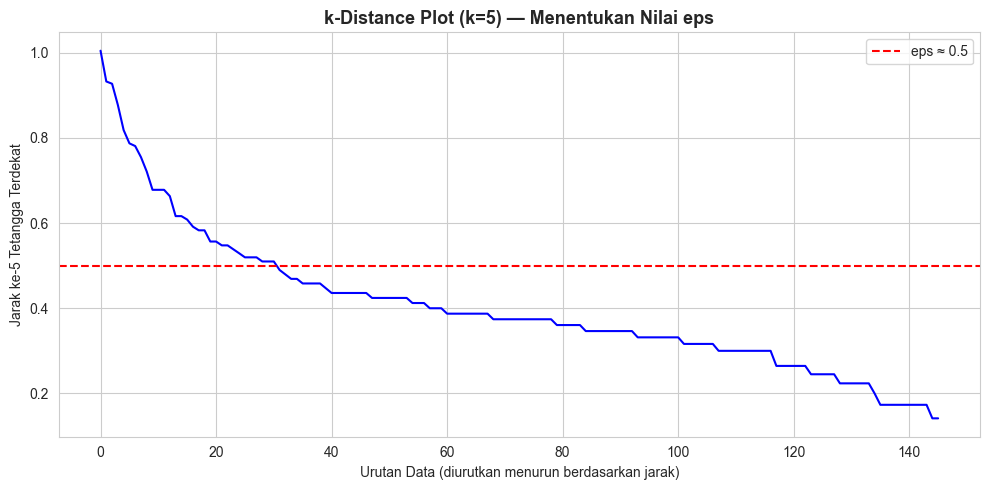

Pilih eps di titik 'elbow' — dijadikan nilai awal: 0.5 (dalam satuan cm, tanpa scaling)


In [45]:
# k-distance plot untuk menentukan eps optimal
min_samples_val = 5
nbrs = NearestNeighbors(n_neighbors=min_samples_val).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances, 'b-', linewidth=1.5)
plt.title(f'k-Distance Plot (k={min_samples_val}) — Menentukan Nilai eps', fontweight='bold')
plt.xlabel('Urutan Data (diurutkan menurun berdasarkan jarak)')
plt.ylabel(f'Jarak ke-{min_samples_val} Tetangga Terdekat')
plt.axhline(y=0.5, color='red', linestyle='--', label='eps ≈ 0.5')
plt.legend()
plt.tight_layout()
plt.show()

print("Pilih eps di titik 'elbow' — dijadikan nilai awal: 0.5 (dalam satuan cm, tanpa scaling)")

Jumlah cluster yang ditemukan: 2
Jumlah noise points           : 16 (11.0%)


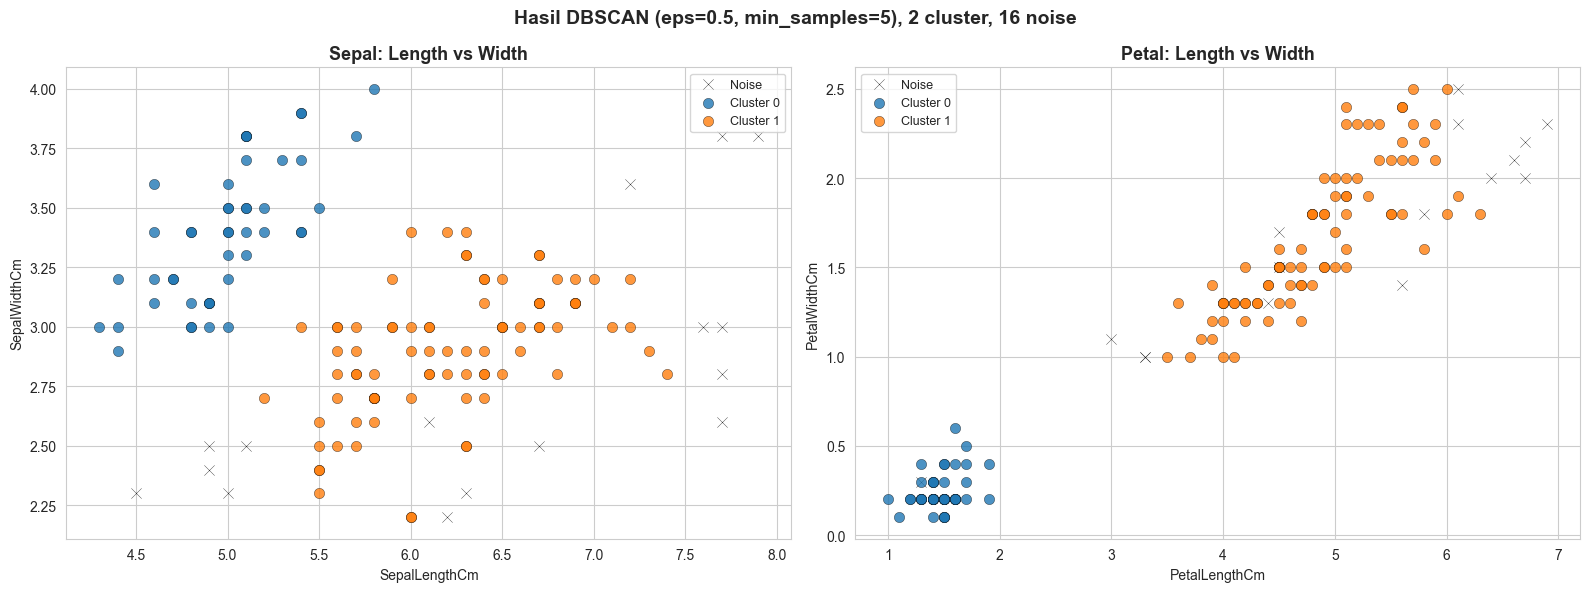


Evaluasi DBSCAN (hanya non-noise)
  Silhouette Score       : 0.7367
  Davies-Bouldin Score   : 0.3365
  Calinski-Harabasz Score: 658.57


In [46]:
# Fit DBSCAN — eps sesuai elbow pada k-distance plot
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db    = int(np.sum(dbscan_labels == -1))

print(f"Jumlah cluster yang ditemukan: {n_clusters_db}")
print(f"Jumlah noise points           : {n_noise_db} ({n_noise_db/len(dbscan_labels)*100:.1f}%)")

scatter_clusters(X, dbscan_labels,
                 f'Hasil DBSCAN (eps=0.5, min_samples=5), {n_clusters_db} cluster, {n_noise_db} noise')

# Evaluasi (hanya pada data bukan noise)
if n_clusters_db > 1:
    mask_valid = dbscan_labels != -1
    sil_db = silhouette_score(X[mask_valid], dbscan_labels[mask_valid])
    db_db  = davies_bouldin_score(X[mask_valid], dbscan_labels[mask_valid])
    ch_db  = calinski_harabasz_score(X[mask_valid], dbscan_labels[mask_valid])
    print(f"\nEvaluasi DBSCAN (hanya non-noise)")
    print(f"  Silhouette Score       : {sil_db:.4f}")
    print(f"  Davies-Bouldin Score   : {db_db:.4f}")
    print(f"  Calinski-Harabasz Score: {ch_db:.2f}")
else:
    sil_db, db_db, ch_db = None, None, None
    print("DBSCAN hanya menemukan 1 cluster — evaluasi tidak dapat dihitung.")

---
## 9. BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies)

BIRCH cocok untuk **dataset besar** karena membangun **CF-Tree** (Clustering Feature Tree) untuk meringkas data secara online sebelum clustering final.

Parameter utama:
- **`threshold`** — radius maksimum sub-cluster (lebih kecil = lebih banyak sub-cluster)
- **`n_clusters`** — jumlah cluster akhir (opsional)

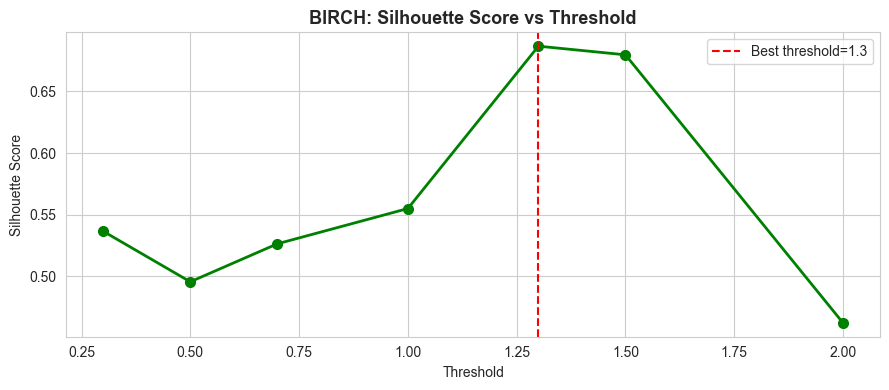

Threshold terbaik: 1.3  (Silhouette = 0.6868)


In [47]:
# Tuning threshold BIRCH menggunakan Silhouette Score
# Tanpa scaling, nilai threshold lebih besar (satuan cm)
thresholds = [0.3, 0.5, 0.7, 1.0, 1.3, 1.5, 2.0, 2.5, 3.0]
birch_sil_scores = []

for thr in thresholds:
    birch_tmp = Birch(threshold=thr, n_clusters=3)
    lbl_tmp = birch_tmp.fit_predict(X)
    if len(set(lbl_tmp)) > 1:
        birch_sil_scores.append(silhouette_score(X, lbl_tmp))
    else:
        birch_sil_scores.append(np.nan)

best_thr_idx = np.nanargmax(birch_sil_scores)
best_thr = thresholds[best_thr_idx]

plt.figure(figsize=(9, 4))
plt.plot(thresholds, birch_sil_scores, 'go-', linewidth=2, markersize=7)
plt.axvline(x=best_thr, color='red', linestyle='--', label=f'Best threshold={best_thr}')
plt.title('BIRCH: Silhouette Score vs Threshold', fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('Silhouette Score')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Threshold terbaik: {best_thr}  (Silhouette = {birch_sil_scores[best_thr_idx]:.4f})")

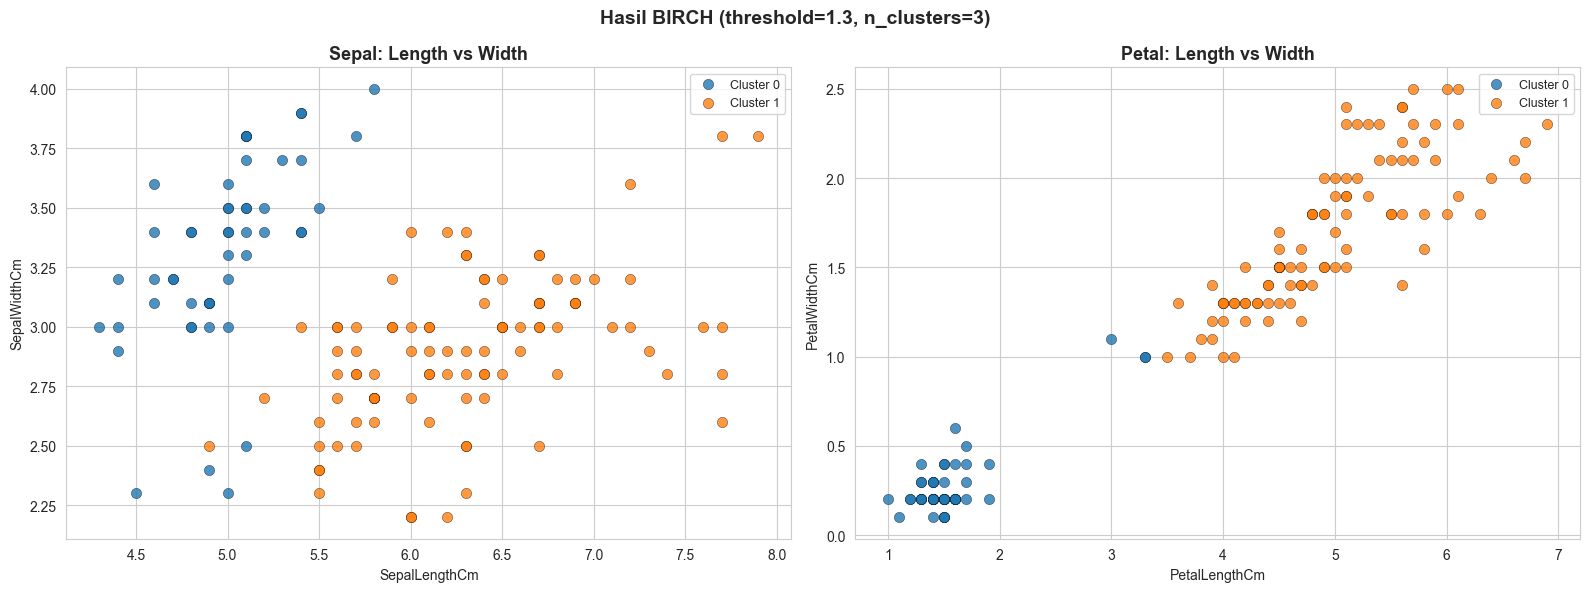

=== Evaluasi BIRCH ===
  Silhouette Score       : 0.6868
  Davies-Bouldin Score   : 0.3944
  Calinski-Harabasz Score: 511.67


In [48]:
# Fit BIRCH dengan parameter terbaik
birch = Birch(threshold=best_thr, n_clusters=3)
birch_labels = birch.fit_predict(X)

scatter_clusters(X, birch_labels,
                 f'Hasil BIRCH (threshold={best_thr}, n_clusters=3)')

# Evaluasi
sil_birch = silhouette_score(X, birch_labels)
db_birch  = davies_bouldin_score(X, birch_labels)
ch_birch  = calinski_harabasz_score(X, birch_labels)

print(f"=== Evaluasi BIRCH ===")
print(f"  Silhouette Score       : {sil_birch:.4f}")
print(f"  Davies-Bouldin Score   : {db_birch:.4f}")
print(f"  Calinski-Harabasz Score: {ch_birch:.2f}")

---
## 10. Perbandingan & Evaluasi Semua Metode

### Metrik Evaluasi (Internal — tanpa ground truth label)
| Metrik | Lebih baik jika... | Rentang |
|---|---|---|
| **Silhouette Score** | Semakin **tinggi** | -1 hingga 1 |
| **Davies-Bouldin Score** | Semakin **rendah** | ≥ 0 |
| **Calinski-Harabasz Score** | Semakin **tinggi** | ≥ 0 |

In [49]:
# Ringkasan evaluasi semua metode
results = {
    'K-Means':      {'Silhouette': sil_km,   'Davies-Bouldin': db_km,   'Calinski-Harabasz': ch_km,   'n_clusters': 3, 'n_noise': 0},
    'Hierarchical': {'Silhouette': sil_agg,  'Davies-Bouldin': db_agg,  'Calinski-Harabasz': ch_agg,  'n_clusters': 3, 'n_noise': 0},
    'DBSCAN':       {'Silhouette': sil_db,   'Davies-Bouldin': db_db,   'Calinski-Harabasz': ch_db,   'n_clusters': n_clusters_db, 'n_noise': n_noise_db},
    'BIRCH':        {'Silhouette': sil_birch,'Davies-Bouldin': db_birch,'Calinski-Harabasz': ch_birch,'n_clusters': 3, 'n_noise': 0},
}

df_results = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Metode'})
df_results['n_clusters'] = df_results['n_clusters'].astype(int)
df_results['n_noise'] = df_results['n_noise'].astype(int)

# Format angka
for col in ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']:
    df_results[col] = pd.to_numeric(df_results[col], errors='coerce').round(4)

print("=" * 75)
print("           TABEL PERBANDINGAN METODE CLUSTERING")
print("=" * 75)
display(df_results.set_index('Metode'))

# Highlight kolom terbaik
sil_best = df_results['Silhouette'].idxmax()
db_best  = df_results['Davies-Bouldin'].idxmin()
ch_best  = df_results['Calinski-Harabasz'].idxmax()

print("\nPemenang per metrik:")
print(f"  Silhouette Score terbaik        : {df_results.loc[sil_best, 'Metode']}  ({df_results.loc[sil_best, 'Silhouette']:.4f})")
print(f"  Davies-Bouldin Score terbaik    : {df_results.loc[db_best, 'Metode']}  ({df_results.loc[db_best, 'Davies-Bouldin']:.4f})")
print(f"  Calinski-Harabasz Score terbaik : {df_results.loc[ch_best, 'Metode']}  ({df_results.loc[ch_best, 'Calinski-Harabasz']:.2f})")

           TABEL PERBANDINGAN METODE CLUSTERING


,Silhouette,Davies-Bouldin,Calinski-Harabasz,n_clusters,n_noise
Metode,,,,,
K-Means,0.6868,0.3944,511.6696,3,0
Hierarchical,0.5559,0.6531,562.4802,3,0
DBSCAN,0.7367,0.3365,658.5689,2,16
BIRCH,0.6868,0.3944,511.6696,3,0



Pemenang per metrik:
  Silhouette Score terbaik        : DBSCAN  (0.7367)
  Davies-Bouldin Score terbaik    : DBSCAN  (0.3365)
  Calinski-Harabasz Score terbaik : DBSCAN  (658.57)


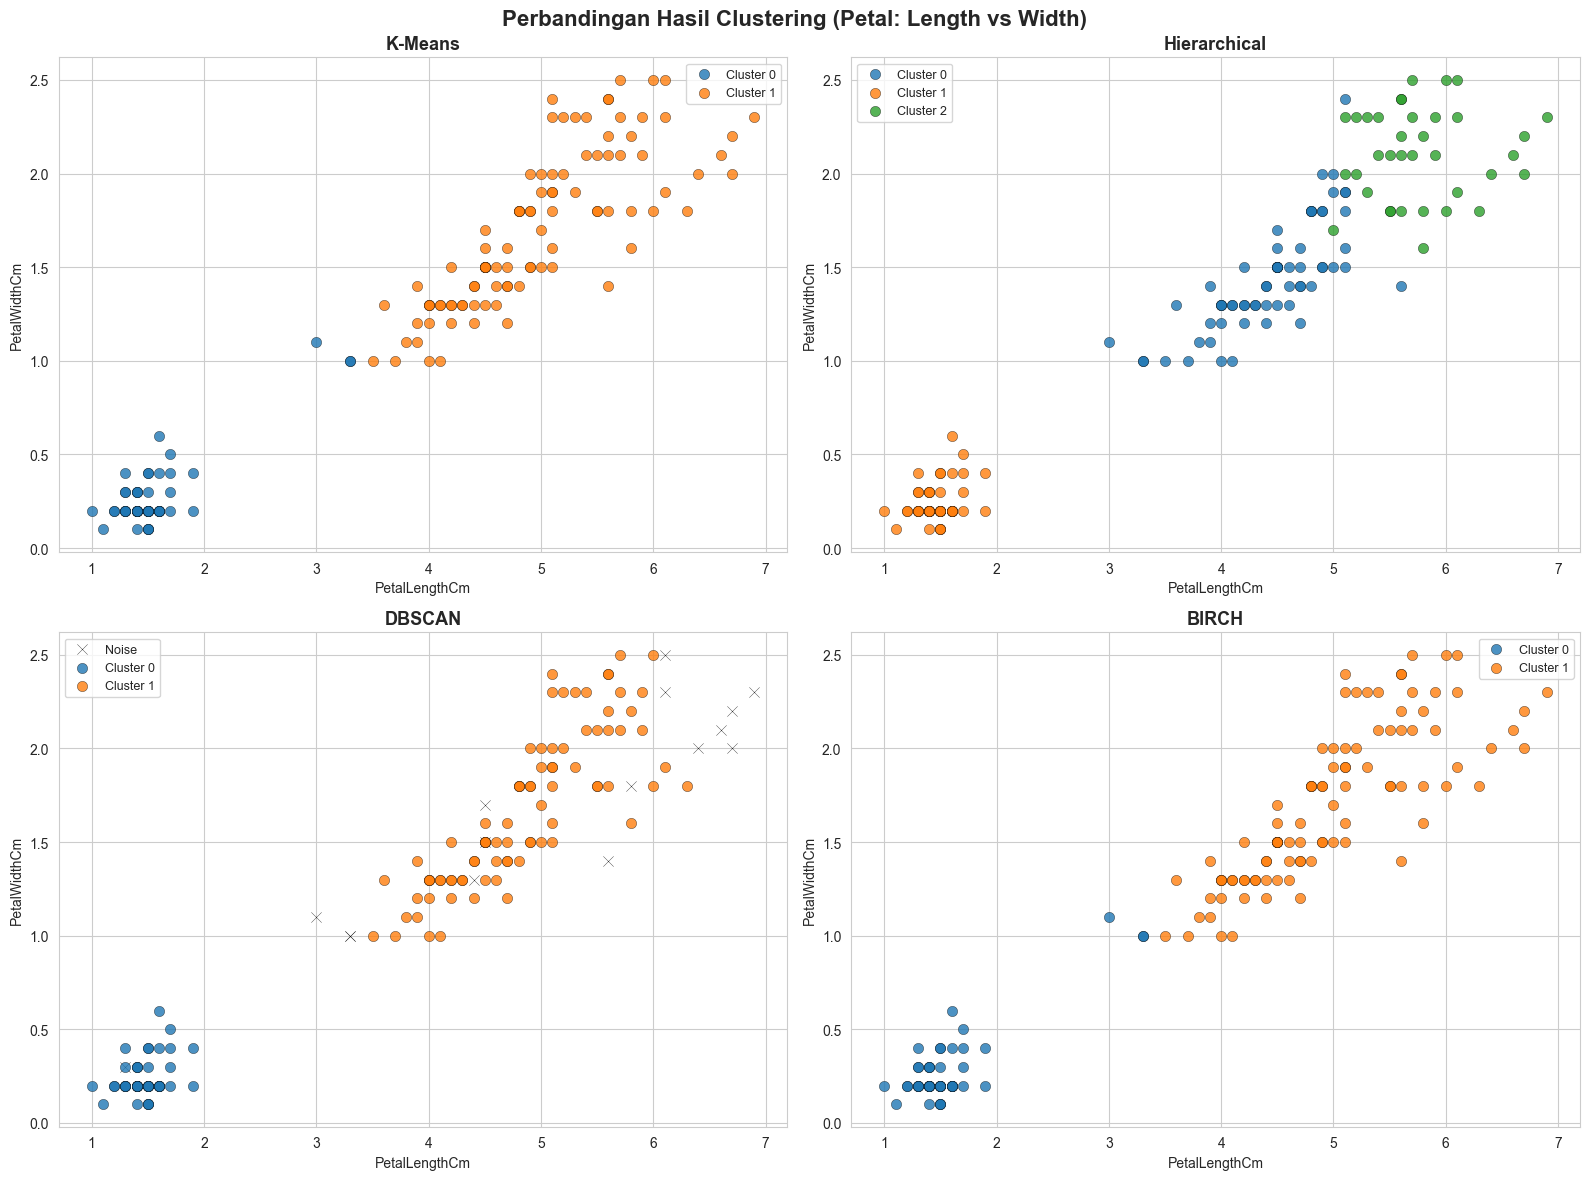

In [50]:
# Visualisasi perbandingan semua metode — Petal scatter (paling diskriminatif)
all_labels = {
    'K-Means': kmeans_labels,
    'Hierarchical': agg_labels,
    'DBSCAN': dbscan_labels,
    'BIRCH': birch_labels,
}
palette = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (name, labels) in zip(axes, all_labels.items()):
    for label in sorted(set(labels)):
        mask = labels == label
        c = 'black' if label == -1 else palette[label % len(palette)]
        m = 'x'    if label == -1 else 'o'
        lbl = 'Noise' if label == -1 else f'Cluster {label}'
        ax.scatter(X[mask, 2], X[mask, 3], c=[c], marker=m,
                   s=55, alpha=0.8, edgecolors='k' if m == 'o' else None,
                   linewidths=0.3, label=lbl)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('PetalLengthCm')
    ax.set_ylabel('PetalWidthCm')
    ax.legend(fontsize=9)

fig.suptitle('Perbandingan Hasil Clustering (Petal: Length vs Width)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

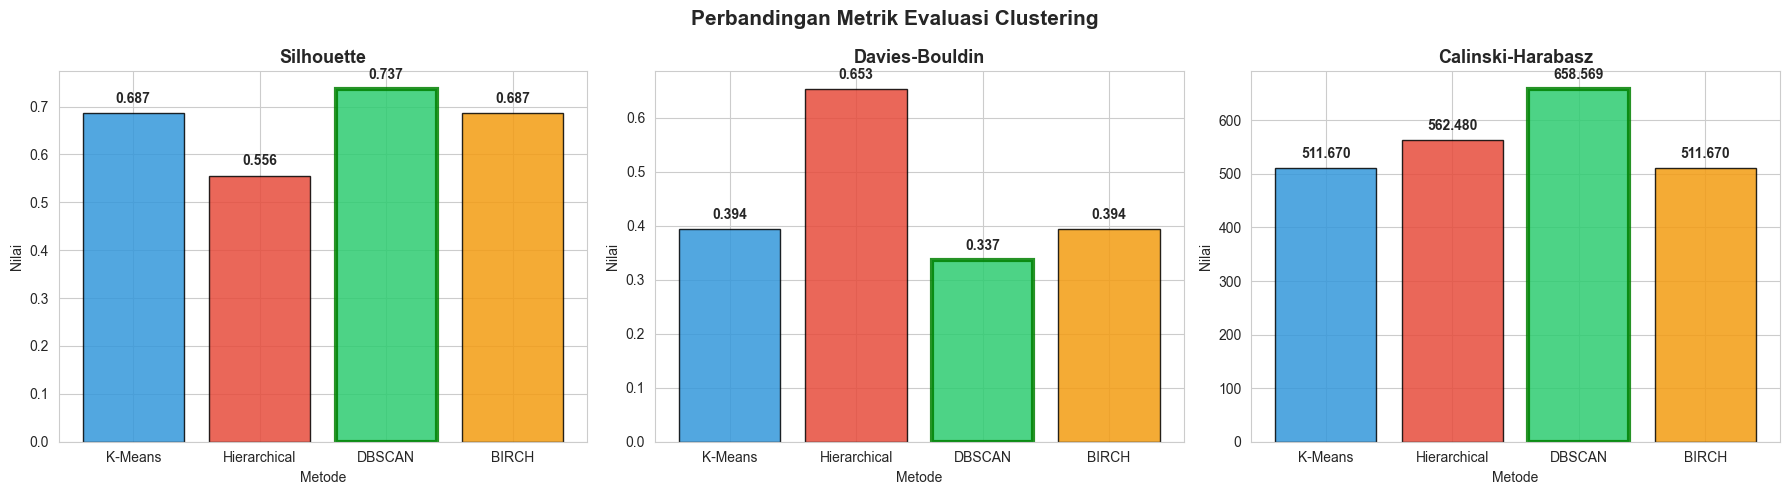


Bar hijau = nilai terbaik untuk metrik tersebut


In [51]:
# Bar chart perbandingan metrik
metrics = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']
methods = df_results['Metode'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, metric in enumerate(metrics):
    vals = df_results[metric].tolist()
    bars = axes[i].bar(methods, vals, color=bar_colors, edgecolor='black', alpha=0.85)
    axes[i].set_title(metric, fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Metode')
    axes[i].set_ylabel('Nilai')
    
    # Anotasi nilai di atas bar
    for bar, val in zip(bars, vals):
        if pd.notna(val):
            axes[i].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + max(vals) * 0.02,
                         f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Highlight terbaik
    if metric == 'Davies-Bouldin':
        best_idx = np.nanargmin(vals)
    else:
        best_idx = np.nanargmax(vals)
    bars[best_idx].set_edgecolor('green')
    bars[best_idx].set_linewidth(3)

plt.suptitle('Perbandingan Metrik Evaluasi Clustering', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nBar hijau = nilai terbaik untuk metrik tersebut")

In [52]:
# Tentukan metode terbaik berdasarkan majority vote dari 3 metrik
all_labels_map = {
    'K-Means': kmeans_labels,
    'Hierarchical': agg_labels,
    'DBSCAN': dbscan_labels,
    'BIRCH': birch_labels,
}

votes = {m: 0 for m in df_results['Metode']}
votes[df_results.loc[df_results['Silhouette'].idxmax(), 'Metode']]        += 1
votes[df_results.loc[df_results['Davies-Bouldin'].idxmin(), 'Metode']]    += 1
votes[df_results.loc[df_results['Calinski-Harabasz'].idxmax(), 'Metode']] += 1

best_method = max(votes, key=votes.get)
best_labels = all_labels_map[best_method]

print(f"Metode terbaik (majority vote): {best_method}")
print(f"  Votes: {votes}")

# Buat output.csv — semua kolom asli + kolom Cluster
df_output = df_clean.copy()
df_output['Cluster'] = best_labels

output_path = 'output.csv'
df_output.to_csv(output_path, index=False)

print(f"\nFile '{output_path}' disimpan ({len(df_output)} baris, {len(df_output.columns)} kolom)")
print(f"Kolom: {list(df_output.columns)}")
print(f"\nDistribusi cluster:")
print(df_output['Cluster'].value_counts().sort_index())
df_output.head()


Metode terbaik (majority vote): DBSCAN
  Votes: {'K-Means': 0, 'Hierarchical': 0, 'DBSCAN': 3, 'BIRCH': 0}

File 'output.csv' disimpan (146 baris, 7 kolom)
Kolom: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species', 'Cluster']

Distribusi cluster:
Cluster
-1    16
 0    46
 1    84
Name: count, dtype: int64


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,1,5.1,3.5,1.4,0.2,Iris-setosa,0
1,2,4.9,3.0,1.4,0.2,Iris-setosa,0
2,3,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5,5.0,3.6,1.4,0.2,Iris-setosa,0


---
## Kesimpulan

| Metode | Kelebihan | Kekurangan |
|---|---|---|
| **K-Means** | Cepat, mudah dipahami, hasil konsisten | Perlu tentukan k, sensitif outlier, hanya cocok untuk cluster bulat |
| **Hierarchical** | Tidak perlu k di awal (bisa dari dendrogram), menghasilkan hirarki | Lambat pada data besar (O(n²) memori), tidak bisa re-assign sampel |
| **DBSCAN** | Bisa deteksi noise/outlier, cluster bebas bentuk, tidak perlu k | Sensitif terhadap eps & min_samples, kurang baik pada cluster dengan density berbeda |
| **BIRCH** | Sangat cepat & efisien memori (cocok data besar), satu pass | Kurang akurat pada cluster non-spherical, threshold sulit diatur |

**Dataset Iris** memiliki cluster yang cukup compact dan well-separated (terutama di dimensi Petal), sehingga **K-Means dan Hierarchical cenderung memberikan hasil terbaik** pada dataset ini.